#### REAL-TIME DETECTION USING DNN in IMAGE AND VIDEO

In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
config_file=r"C:\Users\vv\OneDrive\Desktop\PYTHON\DNN\ssd_mobilenet_v3_large_coco_2020_01_14 (1).pbtxt"
frozen_model=r"C:\Users\vv\OneDrive\Desktop\PYTHON\DNN\frozen_inference_graph.pb"

In [3]:
model=cv2.dnn_DetectionModel(frozen_model, config_file)

In [4]:
classLabels=[]
file_name=r"C:\Users\vv\OneDrive\Desktop\PYTHON\DNN\labels.txt"
with open(file_name, 'rt') as fpt:
    classLabels=fpt.read().rstrip('\n').split('\n')




In [5]:
print(len(classLabels))

80


In [6]:
classLabels

['person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'dining table',
 'toilet',
 'tv',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush']

In [7]:
model.setInputSize(320,320)
model.setInputScale(1.0/127.5)
model.setInputMean((127.5,127,5,127.5))
model.setInputSwapRB(True)

< cv2.dnn.Model 000001BF66B21B70>

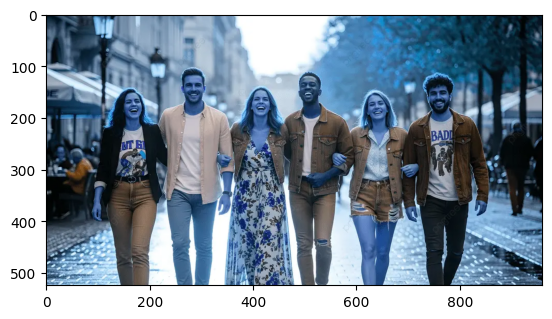

In [8]:
img=cv2.imread(r"C:\Users\vv\OneDrive\Desktop\PYTHON\pngtree-a-diverse-group-of-six-friends-walking-arm-in-arm-down-image_20242225.webp")

plt.imshow(img)

In [9]:
ClassIndex, confidence, bbox=model.detect(img, confThreshold=0.5)

In [10]:
print(ClassIndex)

[1 1 1 1 1 1 1]


In [11]:
font_scale=3
font=cv2.FONT_HERSHEY_PLAIN
for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
    cv2.rectangle(img, boxes, (255,0,0), 2)
    cv2.putText(img, classLabels[ClassInd-1],(boxes[0]+10, boxes[1]+40), font, font_scale, color=(0,255,0),thickness=3)
    

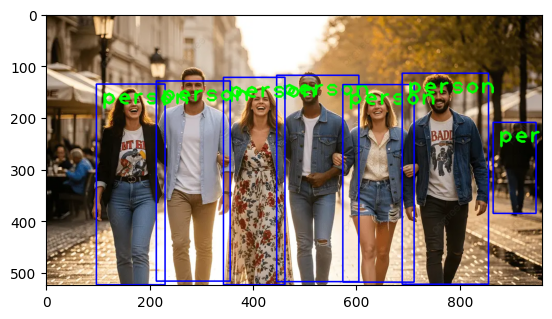

In [12]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [14]:
import cv2

# Load video
cap = cv2.VideoCapture(r"C:\Users\vv\OneDrive\Desktop\PYTHON\DNN\Old Delhi traffic flow _ Near Red Fort with Jain temple view.mp4")

# If video not opened, open webcam
if not cap.isOpened():
    cap = cv2.VideoCapture(0)

# Final check
if not cap.isOpened():
    raise IOError("Cannot open video")

font_scale = 2
font = cv2.FONT_HERSHEY_PLAIN

while True:

    ret, frame = cap.read()

    # End of video
    if not ret or frame is None:
        print("Frame not received")
        break

    # Detect objects
    ClassIndex, confidence, bbox = model.detect(frame, confThreshold=0.55)

    print(ClassIndex)

    if len(ClassIndex) != 0:

        for ClassInd, conf, boxes in zip(ClassIndex.flatten(),
                                         confidence.flatten(),
                                         bbox):

            if ClassInd <= 80:
                cv2.rectangle(frame, boxes, (255, 0, 0), 2)

                cv2.putText(frame,
                            classLabels[ClassInd-1],
                            (boxes[0] + 10, boxes[1] + 40),
                            font,
                            font_scale,
                            (0, 255, 0),
                            2)

    # Show frame
    cv2.imshow("Object Detection", frame)

    # ESC key to exit
    if cv2.waitKey(1) & 0xFF == 27:
        break

# Release resources
cap.release()
cv2.destroyAllWindows()

()
[1 7]
[1 8]
[8 1 1]
[6 1 1]
[1 6 1 1 8]
[6 8]
[8 6 1]
[6 1 8]
[6 8 1]
[6 8]
[8 6]
[6 8]
[6 8 1 1]
[6 1 8 1 3]
[1 6 1 1 8 3]
[1 6 1 3 8 1]
[1 6 8 3 8]
[6 1 3 8 1]
[6 1 8 3]
[6 1 3 8]
[6 1 8 3]
[1 6 1 3 8 1]
[6 1 3 6]
[6 8 3 4 1]
[6 8 4 3]
[6 8 6 3 4]
[6 8 4 1 3]
[6 8 1 4]
[6 8 4 1]
[1 6 6 1 1]
[1 6 1 8 1 6]
[1 6 8 1 1 4 4 1 6]
[1 6 1 8 4 1]
[1 6 1 1 8 1]
[1 6 1 1 4 8 1]
[6 1 4 8 1 1 3]
[6 1 1 4 8 1 4 1]
[6 4 1 1 1 8 1]
[6 4 1 8 1 1 3 4]
[1 6 1 4 8 1]
[6 1 4 8 1 4 1]
[1 6 4 1 8 4 1]
[4 6 8 1 1 1]
[4 6 1 8 4 3 1 1 1]
[6 1 4 4 8 1 1]
[1 6 4 1 8 1 1]
[1 6 4 1 8 1 1 4]
[1 6 4 8 4]
[1 6 4 1 1 8]
[6 1 4 8 1 1 4 4]
[1 6 4 1 1 8 3]
[1 6 4 1 1 1 8]
[1 6 4 1 1 1 8 1]
[1 6 4 1 1 8]
[1 6 1 4 8 1]
[1 6 1 4 1 8 1 1]
[1 6 1 4 1 8 1 4 1]
[1 6 4 1 1 8 1 1]
[6 4 1 1 1 8 1]
[1 6 4 1 1 1 8]
[1 6 1 1 1 4 4 3 1]
[1 1 4 6 1 1 3]
[1 1 1 6 4 1 1 1]
[1 6 1 1 1 4 1]
[1 1 6 1 1 1 1 4]
[1 1 1 6 1 1]
[1 1 6 1 1 3]
[1 6 1 1]
[6 1 1 3 1]
[6 1 3]
[6 1 4 1]
[6 4 1 1 1 1]
[6 1 4 1 1 1 1]
[6 4 1 1 1 1]
[6 4 1 1 1 1]
[6 